# Importamos paquetes

In [1]:
import numpy as np #hacer cálculos matemáticos
import pandas as pd #trabajar con tablas y datos
import matplotlib.pyplot as plt #realizar gráficos
import seaborn as sns #visualizaciones estadísticas
%matplotlib inline

# Importamos el conjunto de datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/PM2.5_daily_aqs_data_downloaded_2026.csv")
df.head() #vemos los 5 primeros datos del data frame

,Date,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-02,10030010,1,5.3,Micrograms/cubic meter (LC),29,"FAIRHOPE, Alabama",1,100,88101,...,37.19,NEIGHBORHOOD,500 M TO 4KM,NaN,Al Dept Of Env Mgt,POPULATION EXPOSURE,NaN,NaN,10,NaN
1,2022-01-05,10030010,1,8.6,Micrograms/cubic meter (LC),48,"FAIRHOPE, Alabama",1,100,88101,...,37.19,NEIGHBORHOOD,500 M TO 4KM,NaN,Al Dept Of Env Mgt,POPULATION EXPOSURE,NaN,NaN,10,NaN
2,2022-01-08,10030010,1,8.5,Micrograms/cubic meter (LC),47,"FAIRHOPE, Alabama",1,100,88101,...,37.19,NEIGHBORHOOD,500 M TO 4KM,NaN,Al Dept Of Env Mgt,POPULATION EXPOSURE,NaN,NaN,10,NaN
3,2022-01-11,10030010,1,3.7,Micrograms/cubic meter (LC),21,"FAIRHOPE, Alabama",1,100,88101,...,37.19,NEIGHBORHOOD,500 M TO 4KM,NaN,Al Dept Of Env Mgt,POPULATION EXPOSURE,NaN,NaN,10,NaN
4,2022-01-14,10030010,1,11.6,Micrograms/cubic meter (LC),56,"FAIRHOPE, Alabama",1,100,88101,...,37.19,NEIGHBORHOOD,500 M TO 4KM,NaN,Al Dept Of Env Mgt,POPULATION EXPOSURE,NaN,NaN,10,NaN


Los primeros registros muestran las mediciones diarias de PM2.5, el valor diario del AQI y la información asociada al punto de monitoreo.

# Consultamos la informacion básica sobre el conjunto de datos

In [5]:
df.info(verbose=True)

#describe permite dar un resumen estadistico, acondiciono redondeo
display(df.describe().round(2))

#para ver las caracteristicas
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            451 non-null    object 
 1   Site ID                         451 non-null    int64  
 2   POC                             451 non-null    int64  
 3   Daily Mean PM2.5 Concentration  451 non-null    float64
 4   Units                           451 non-null    object 
 5   Daily AQI Value                 451 non-null    int64  
 6   Local Site Name                 451 non-null    object 
 7   Daily Obs Count                 451 non-null    int64  
 8   Percent Complete                451 non-null    int64  
 9   AQS Parameter Code              451 non-null    int64  
 10  AQS Parameter Description       451 non-null    object 
 11  Method Code                     451 non-null    int64  
 12  Method Description              451 

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Elevation (m),Networks,Probe Height (m),QA Primary Monitor?
count,451.0,451.00,451.00,451.00,451.0,451.0,451.0,451.00,451.0,451.0,451.00,451.00,0.0,451.0,0.0
mean,10030010.0,2.49,7.54,38.52,1.0,100.0,88101.0,192.68,19300.0,30.5,-87.88,37.19,NaN,10.0,NaN
std,0.0,0.87,4.04,15.38,0.0,0.0,0.0,27.93,0.0,0.0,0.00,0.00,NaN,0.0,NaN
min,10030010.0,1.00,0.00,0.00,1.0,100.0,88101.0,145.00,19300.0,30.5,-87.88,37.19,NaN,10.0,NaN
25%,10030010.0,1.00,4.85,27.00,1.0,100.0,88101.0,145.00,19300.0,30.5,-87.88,37.19,NaN,10.0,NaN
50%,10030010.0,3.00,6.90,38.00,1.0,100.0,88101.0,209.00,19300.0,30.5,-87.88,37.19,NaN,10.0,NaN
75%,10030010.0,3.00,9.60,52.00,1.0,100.0,88101.0,209.00,19300.0,30.5,-87.88,37.19,NaN,10.0,NaN
max,10030010.0,3.00,33.60,97.00,1.0,100.0,88101.0,209.00,19300.0,30.5,-87.88,37.19,NaN,10.0,NaN


Index(['Date', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration', 'Units',
       'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'Site Latitude', 'Site Longitude', 'Dominant Source', 'Elevation (m)',
       'Measurement Scale', 'Measurement Scale Definition', 'Monitor Type',
       'Monitoring Agency', 'Monitoring Objective', 'NAAQS Primary Monitor?',
       'Networks', 'Probe Height (m)', 'QA Primary Monitor?'],
      dtype='object')

El conjunto de datos contiene 451 registros. La concentración media diaria de PM2.5 es aproximadamente 7.54 µg/m³ y el AQI promedio es 38.52.

# Visualizacion básica

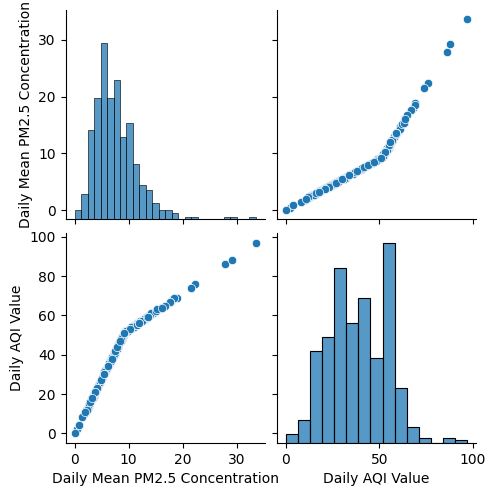

In [6]:
#Visualización básica de las variables principales
df_modelo = df[["Daily Mean PM2.5 Concentration", "Daily AQI Value"]]
sns.pairplot(df_modelo)

Se observa una relación creciente entre la concentración diaria de PM2.5 y el valor diario del AQI.

# Distribución de PM2.5

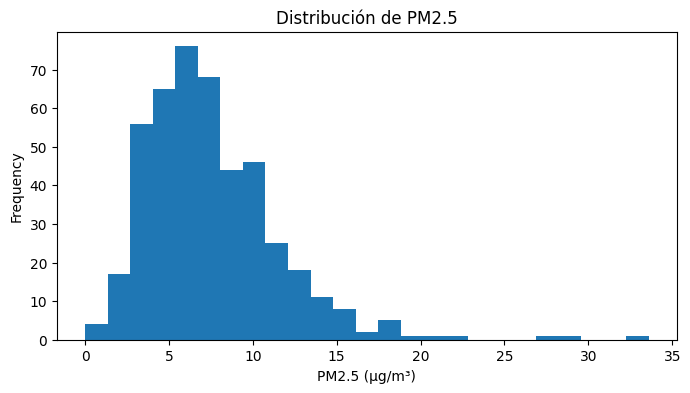

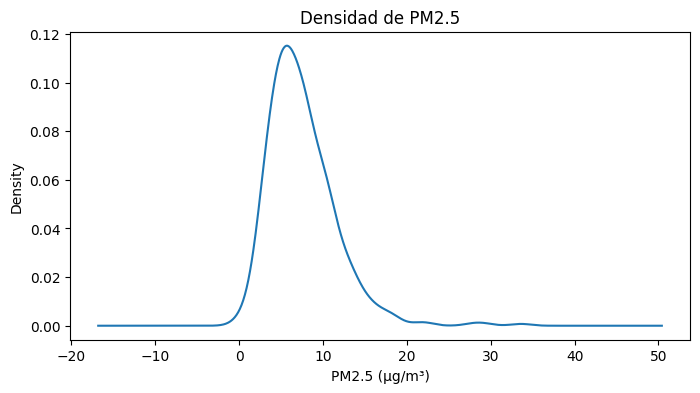

In [8]:
#histograma de la concentración diaria de PM2.5
df["Daily Mean PM2.5 Concentration"].plot.hist(bins=25, figsize=(8,4))
plt.xlabel("PM2.5 (µg/m³)")
plt.title("Distribución de PM2.5")
plt.show()

#densidad: ¿Dónde están concentrados los datos?
df["Daily Mean PM2.5 Concentration"].plot.density(figsize=(8,4))
plt.xlabel("PM2.5 (µg/m³)")
plt.title("Densidad de PM2.5")
plt.show()

La mayor parte de las mediciones se concentra en valores bajos y medios de PM2.5. La media es 7.54 µg/m³ y la mediana es 6.90 µg/m³, mientras que el valor máximo registrado es 33.60 µg/m³.

# Matriz de correlación y heatmap

,Daily Mean PM2.5 Concentration,Daily AQI Value
Daily Mean PM2.5 Concentration,1.0000,0.9499
Daily AQI Value,0.9499,1.0000


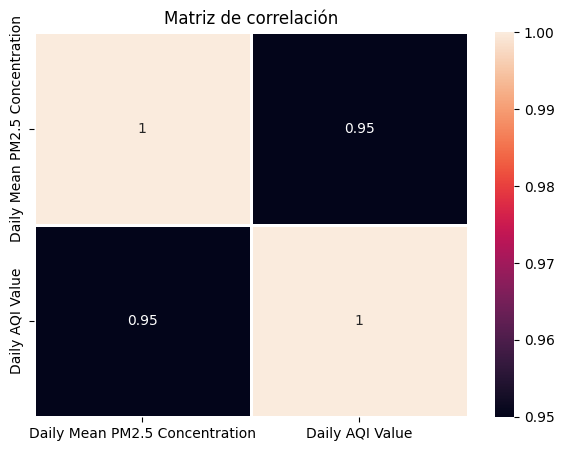

In [9]:
numeric_df = df_modelo.select_dtypes(include=[np.number])
#selecciona solo las columnas con valores numericos
display(numeric_df.corr().round(4))
#calculo de la correlacion relacion entre dos variables

plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2)
plt.title("Matriz de correlación")
plt.show()

La correlación entre PM2.5 y AQI es aproximadamente 0.9499. Esto muestra una relación positiva fuerte: cuando aumenta la concentración de PM2.5, generalmente también aumenta el AQI.

# Variables para el modelo

In [10]:
l_column = list(df_modelo.columns) #haciendo una lista de las columnas
len_feature = len(l_column) #longitud de la lista de vectores de columna
print(l_column)

x = df_modelo[[l_column[0]]]
y = df_modelo[l_column[1]]

display(x.head())
display(y.head())

['Daily Mean PM2.5 Concentration', 'Daily AQI Value']


,Daily Mean PM2.5 Concentration
0,5.3
1,8.6
2,8.5
3,3.7
4,11.6


,Daily AQI Value
0,29
1,48
2,47
3,21
4,56


Para el modelo se utiliza la concentración diaria de PM2.5 como variable de entrada y el AQI como variable que se desea predecir.

# Regresión lineal

# Dividimos entrenamiento-prueba

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
)

print("Datos de entrenamiento:", len(x_train))
print("Datos de prueba:", len(x_test))

Datos de entrenamiento: 315
Datos de prueba: 136


El 70 % de los datos se utiliza para entrenar el modelo y el 30 % restante para comprobar su comportamiento con datos de prueba.

# Ajuste y entrenamiento del modelo

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
#machine learning
#modelo: regresion lineal
#metricas: ¿qué tan buenas son las predicciones?

lm = LinearRegression()
lm.fit(x_train, y_train)

#verificamos la intercepcion
print("el termino de interseccion del modelo lineal: ", lm.intercept_)

#verificamos el modelo lineal
print("los coeficientes del modelo lineal", lm.coef_)

cdf = pd.DataFrame(
    data=lm.coef_,
    index=x_train.columns,
    columns=["Coeficiente"]
)
cdf

el termino de interseccion del modelo lineal:  11.824822213300628
los coeficientes del modelo lineal [3.54066549]


,Coeficiente
Daily Mean PM2.5 Concentration,3.540665


El coeficiente de PM2.5 es aproximadamente 3.54. Según el modelo, por cada aumento de 1 µg/m³ de PM2.5, el AQI aumenta en promedio alrededor de 3.54 puntos.

# Cálculo de errores estándar y estadística t para los coeficientes

,Coeficiente,Standard Error,t-statistic
Daily Mean PM2.5 Concentration,3.540665,0.067688,52.30884


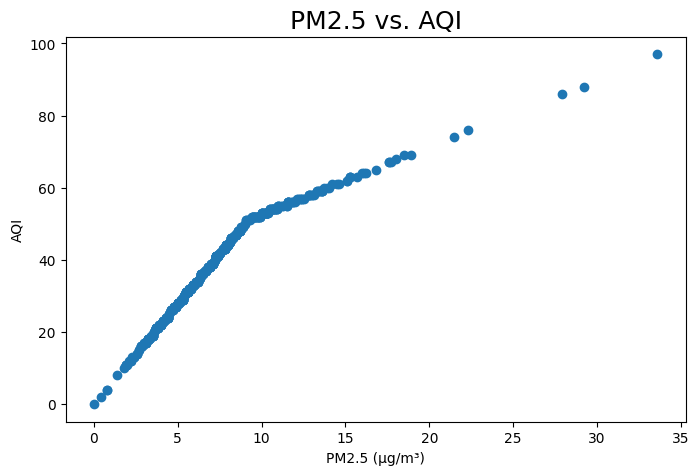

In [13]:
n = x_train.shape[0]
k = x_train.shape[1]
dfN = n-k
train_pred = lm.predict(x_train)

train_error = np.square(train_pred-y_train)
sum_error = np.sum(train_error)

se = []
for i in range(k):
    r = sum_error/dfN
    r = r/np.sum(
        np.square(
            x_train[list(x_train.columns)[i]] -
            x_train[list(x_train.columns)[i]].mean()
        )
    )
    se.append(np.sqrt(r))

cdf["Standard Error"] = se
cdf["t-statistic"] = cdf["Coeficiente"]/cdf["Standard Error"]
display(cdf)

plt.figure(figsize=(8,5))
plt.scatter(df_modelo["Daily Mean PM2.5 Concentration"], df_modelo["Daily AQI Value"])
plt.title("PM2.5 vs. AQI", fontsize=18)
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("AQI")
plt.show()

El coeficiente presenta una estadística t elevada, lo que refleja que existe una asociación lineal marcada entre PM2.5 y AQI en estos datos.

# Matrices de evaluación

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (136,)
MAE: 3.7854
MSE: 21.3677
R²: 0.9129


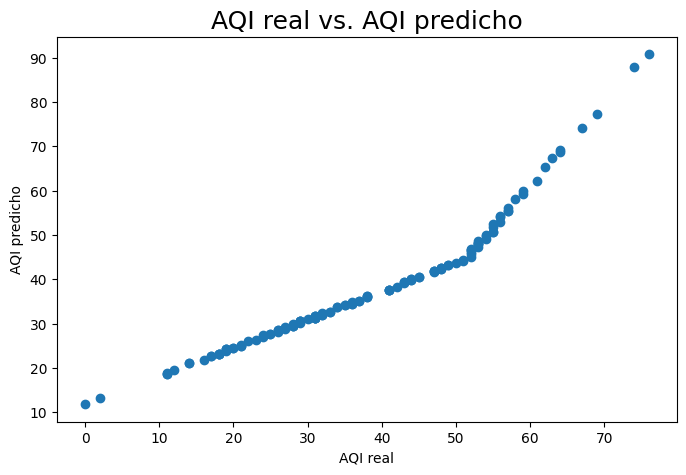

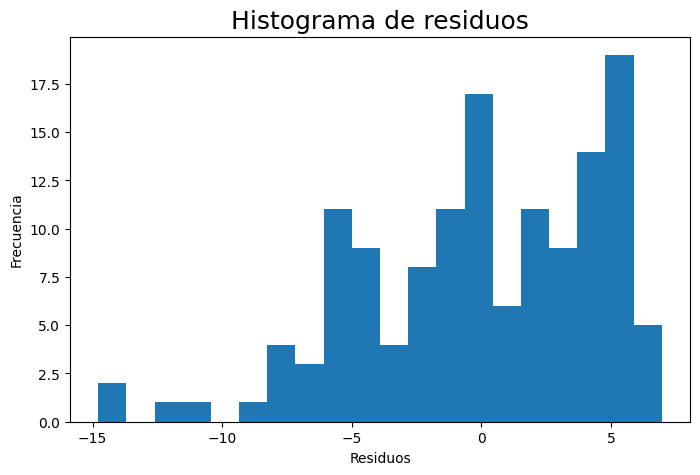

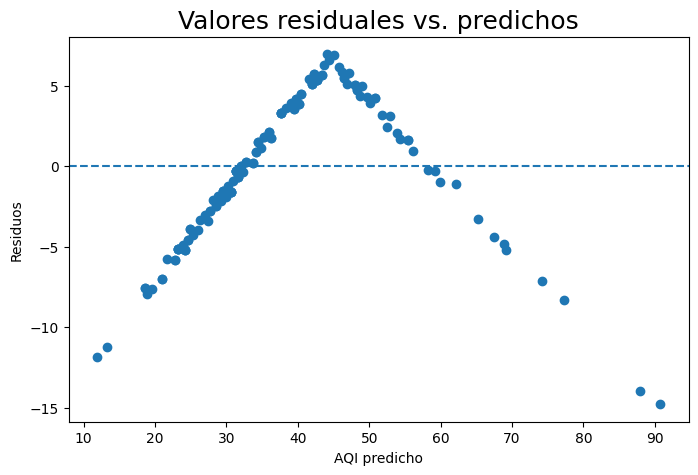

In [15]:
predictions = lm.predict(x_test)

print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)
print("MAE:", round(metrics.mean_absolute_error(y_test, predictions), 4))
print("MSE:", round(metrics.mean_squared_error(y_test, predictions), 4))
print("R²:", round(metrics.r2_score(y_test, predictions), 4))

#DIAGRAMA DE DISPERSION
plt.figure(figsize=(8,5))
plt.title("AQI real vs. AQI predicho", fontsize=18)
plt.xlabel("AQI real")
plt.ylabel("AQI predicho")
plt.scatter(x=y_test, y=predictions)
plt.show()

#HISTOGRAMA DE RESIDUOS
residuos = y_test-predictions
plt.figure(figsize=(8,5))
plt.title("Histograma de residuos", fontsize=18)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.hist(residuos, bins=20)
plt.show()

#DIAGRAMA DE DISPERSION DE RESIDUOS
plt.figure(figsize=(8,5))
plt.title("Valores residuales vs. predichos", fontsize=18)
plt.xlabel("AQI predicho")
plt.ylabel("Residuos")
plt.scatter(x=predictions, y=residuos)
plt.axhline(0, linestyle="--")
plt.show()

La regresión lineal obtiene un R² aproximado de 0.9129 en los datos de prueba. El MAE es aproximadamente 3.79 puntos de AQI, por lo que las predicciones se encuentran relativamente cerca de los valores reales.

# Random Forest

Mean square error (MSE): 0.8949036764705884
R²: 0.9963507560785683
Importancia relativa de las características: [1.]


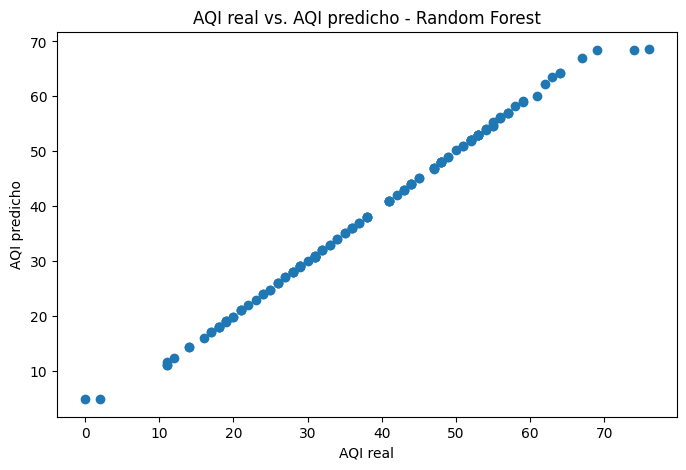

In [16]:
from sklearn.ensemble import RandomForestRegressor

#Creación del modelo
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=10
)
forest_model.fit(x_train, y_train)

#Hacemos predicciones
test_pred = forest_model.predict(x_test)

print("Mean square error (MSE):",
      metrics.mean_squared_error(y_test, test_pred))
print("R²:",
      metrics.r2_score(y_test, test_pred))
print("Importancia relativa de las características:",
      forest_model.feature_importances_)

plt.figure(figsize=(8,5))
plt.scatter(x=y_test, y=test_pred)
plt.title("AQI real vs. AQI predicho - Random Forest")
plt.xlabel("AQI real")
plt.ylabel("AQI predicho")
plt.show()

Random Forest obtiene un R² aproximado de 0.9964 en el conjunto de prueba. En este modelo, PM2.5 es la única característica utilizada y, por lo tanto, concentra toda la importancia del modelo.

# Minimos Cuadrados

In [17]:
import statsmodels.api as sm

Xs = sm.add_constant(x)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:        Daily AQI Value   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     4150.
Date:                Fri, 18 Sep 2026   Prob (F-statistic):          5.79e-229
Time:                        22:54:57   Log-Likelihood:                -1347.4
No. Observations:                 451   AIC:                             2699.
Df Residuals:                     449   BIC:                             2707.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

El modelo de mínimos cuadrados obtiene un R² aproximado de 0.9024 usando todos los registros. El coeficiente de PM2.5 es positivo, confirmando la relación directa observada entre PM2.5 y AQI.